# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


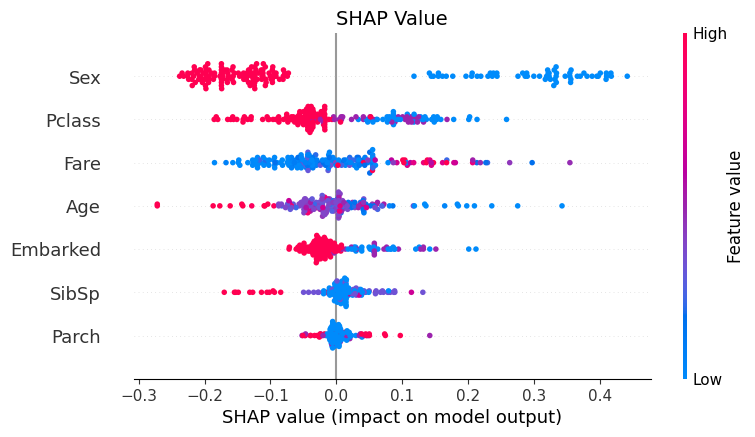

Stacking F1: 0.765625


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

In [ ]:
import pandas as pd 
df = pd.read_csv('Bank Customer Churn Prediction.csv')  # 데이터 불러오기
print(df.head())  # 상위 행 확인
print(df.shape)  # 데이터 크기 확인
print(df.info())  # 변수 타입과 결측치 확인
print(df.isnull().sum())  # 결측치 개수 확인
print(df['churn'].value_counts())  # 타겟 분포 확인
print(df['churn'].value_counts(normalize=True))  # 타겟 비율 확인

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
(10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 # 

In [41]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()  # 수치형 변수 추출
cat_cols = df.select_dtypes(include='object').columns.tolist()  # 범주형 변수 추출

print('수치형 변수:', num_cols)  # 수치형 변수 확인
print('범주형 변수:', cat_cols)  # 범주형 변수 확인

수치형 변수: ['customer_id', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']
범주형 변수: ['country', 'gender']


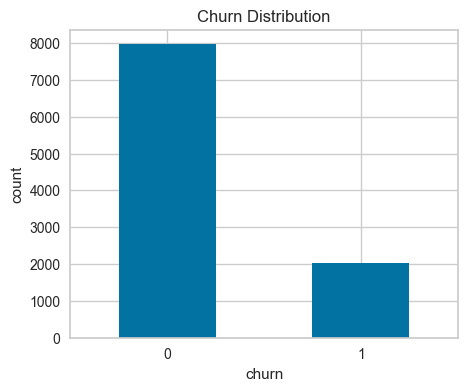

In [ ]:
import matplotlib.pyplot as plt  # 시각화

plt.figure(figsize=(5, 4))  # 그래프 크기 설정
df['churn'].value_counts().sort_index().plot(kind='bar')  # churn 분포 확인
plt.title('Churn Distribution')  # 그래프 제목
plt.xlabel('churn')  # x축 이름
plt.ylabel('count')  # y축 이름
plt.xticks(rotation=0)  # x축 글자 회전 안줌
plt.show()  # 그래프 출력

- 이탈하지 않은 고객이 훨씬 많아 클래스 불균형이 존재함을 확인할 수 있습니다.

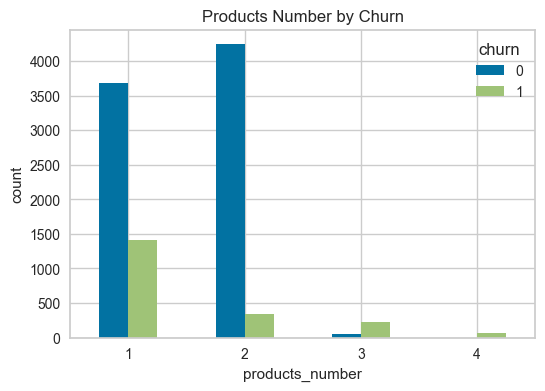

In [ ]:
pd.crosstab(df['products_number'], df['churn']).plot(kind='bar', figsize=(6, 4))  # 상품 수에 따른 churn 분포 확인
plt.title('Products Number by Churn')  # 그래프 제목
plt.xlabel('products_number')  # x축 이름
plt.ylabel('count')  # y축 이름
plt.xticks(rotation=0)  # x축 글자 회전 안줌
plt.show()  # 그래프 출력

- 상품 수에 따라 이탈 분포 차이가 뚜렷하게 나타나며, 특히 3개 이상 구간은 이탈과의 관련성이 커 보입니다.

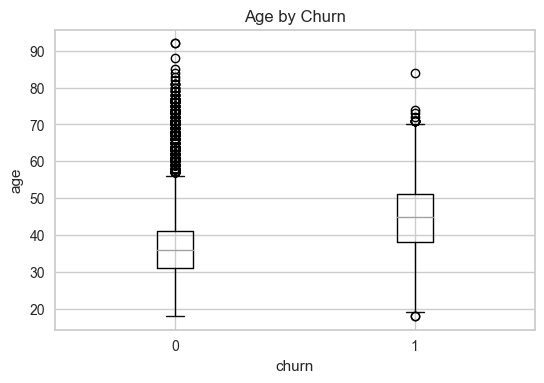

In [37]:
df.boxplot(column='age', by='churn', figsize=(6, 4))  # churn 여부에 따른 age 분포 확인
plt.title('Age by Churn')  # 그래프 제목
plt.suptitle('')  # 기본 제목 제거
plt.xlabel('churn')  # x축 이름
plt.ylabel('age')  # y축 이름
plt.show()  # 그래프 출력

- 이탈 고객의 연령대가 전반적으로 더 높게 나타나 age가 중요한 변수일 가능성을 확인할 수 있습니다.

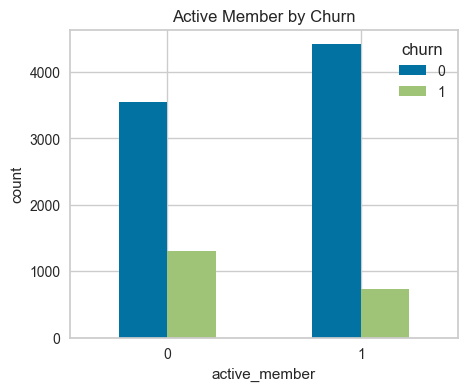

In [ ]:
pd.crosstab(df['active_member'], df['churn']).plot(kind='bar', figsize=(5, 4))  # 활동 여부에 따른 churn 분포 확인
plt.title('Active Member by Churn')  # 그래프 제목
plt.xlabel('active_member')  # x축 이름
plt.ylabel('count')  # y축 이름
plt.xticks(rotation=0)  # x축 글자 회전 안줌
plt.show()  # 그래프 출력

- 비활동 고객에서 이탈 비율이 더 높게 나타나 active_member가 이탈 예측에 의미 있는 변수로 볼 수 있습니다.

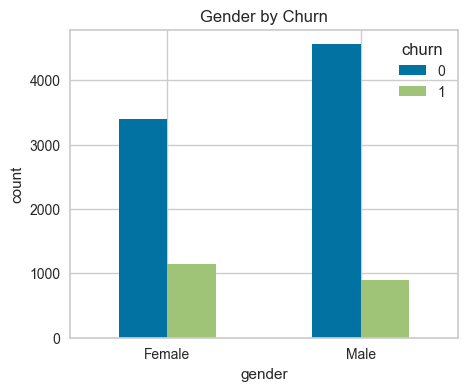

In [ ]:
pd.crosstab(df['gender'], df['churn']).plot(kind='bar', figsize=(5, 4))  # 성별에 따른 churn 분포 확인
plt.title('Gender by Churn')  # 그래프 제목
plt.xlabel('gender')  # x축 이름
plt.ylabel('count')  # y축 이름
plt.xticks(rotation=0)  # x축 글자 회전 안줌
plt.show()  # 그래프 출력

- 성별에 따라 이탈 분포 차이가 일부 나타나지만, 핵심 변수들에 비해서는 영향이 상대적으로 작아 보입니다.

In [ ]:
from sklearn.preprocessing import LabelEncoder 

data = df.copy()  # 원본 데이터 보호를 위해 복사본 생성
data = data.drop(columns=['customer_id'], errors='ignore')  # 예측에 불필요한 컬럼 제거

# 범주형 데이터를 숫자로 변환하기 위한 인코더 정의
le_country = LabelEncoder()  
le_gender = LabelEncoder()  

#문자열 컬럼을 모델이 학습 가능한 숫자 리스트로 변환
data['country'] = le_country.fit_transform(data['country'])
data['gender'] = le_gender.fit_transform(data['gender'])

In [ ]:
from sklearn.model_selection import train_test_split 

X = data.drop(columns='churn')  # 독립변수
y = data['churn']  # 종속변수

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # 8:2로 쪼개기

train_df = pd.concat([X_train, y_train], axis=1)  # 모델 학습에 사용할 데이터 생성
valid_df = pd.concat([X_valid, y_valid], axis=1)  # 검증용 데이터 생성

- customer_id는 고객을 구분하기 위한 식별자 성격의 변수이므로 예측 변수에서 제외하였습니다.
- country와 gender는 문자열 형태의 범주형 변수이므로 모델 학습이 가능하도록 숫자형으로 변환하였습니다.
- 결측치 확인 결과 모든 변수에서 결측치가 존재하지 않아 추가적인 결측치 처리 과정은 수행하지 않았습니다.


In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

from pycaret.classification import * 

clf = setup(
    data=train_df,  # 학습용 데이터 사용
    target='churn',  # 타겟 변수 설정
    session_id=42,  # 시드 고정
    verbose=False,  # 불필요한 출력 최소화
    html=False  # 출력 화면 단순화
)

top4_models = compare_models(sort='F1', n_select=4)  # F1 기준 상위 4개 모델 선택

leaderboard = pull()  # 모델 비교 결과표 저장
print(leaderboard.head(4))  # 상위 4개 결과 확인

                                    Model  Accuracy     AUC  Recall   Prec.  \
catboost              CatBoost Classifier    0.8641  0.8583  0.4839  0.7701   
lightgbm  Light Gradient Boosting Machine    0.8579  0.8495  0.4935  0.7287   
gbc          Gradient Boosting Classifier    0.8643  0.8565  0.4614  0.7912   
xgboost         Extreme Gradient Boosting    0.8507  0.8346  0.4996  0.6895   
ada                  Ada Boost Classifier    0.8568  0.8389  0.4735  0.7352   
rf               Random Forest Classifier    0.8580  0.8393  0.4588  0.7541   
et                 Extra Trees Classifier    0.8507  0.8344  0.4344  0.7291   
dt               Decision Tree Classifier    0.7868  0.6865  0.5161  0.4829   
qda       Quadratic Discriminant Analysis    0.8366  0.8107  0.3189  0.7379   
lda          Linear Discriminant Analysis    0.8021  0.7562  0.1946  0.5571   
lr                    Logistic Regression    0.8104  0.7375  0.1790  0.6456   
ridge                    Ridge Classifier    0.8004 

### 상위 모델 4개 선정 결과 해석

- 여러 분류 모델을 동일한 조건에서 비교한 결과, F1 score 기준 상위 4개 모델은 CatBoost, LightGBM, GBC, XGBoost로 나왔습니다.
- CatBoost의 F1 score는 0.5934로 가장 높게 나타났으며, LightGBM은 0.5869, GBC는 0.5812, XGBoost는 0.5787로 나왔습니다.
- 이번 데이터는 churn 클래스 비율이 불균형하므로 accuracy보다 f1 score를 우선 기준으로 모델을 선정하는 것이 적절하다고 판단했습니다.
- accuracy만 보면 GBC가 0.8643으로 가장 높았지만, 불균형 데이터를 고려할 때 f1 score가 더 타당한 평가 기준이라 판단했습니다.
- 따라서 f1 score 기준 상위 4개 모델인 CatBoost, LightGBM, GBC, XGBoost를 optuna튜닝을 진행하도록 결정하였습니다.

In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)
import optuna  

from catboost import CatBoostClassifier  
from lightgbm import LGBMClassifier  
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier  

from sklearn.metrics import f1_score  

def cat_objective(trial):  # CatBoost의 최적 하이퍼파라미터를 찾기 위한 함수 정의
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500), # 파라미터 옵션 설정
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10)
    }  # CatBoost의 주요 하이퍼파라미터 탐색 범위를 설정

    model = CatBoostClassifier(**params, random_state=42, verbose=0)  # 제안된 파라미터로 CatBoost 모델 생성
    model.fit(X_train, y_train)  # 학습용 데이터로 모델 피팅
    pred = model.predict(X_valid)  # 검증용 데이터에 대한 예측 진행

    return f1_score(y_valid, pred)  # 검증 데이터 기준 F1 score를 반환


study_cat = optuna.create_study(direction='maximize')  # F1 score를 최대화하는 방향으로 CatBoost 튜닝을 진행
study_cat.optimize(cat_objective, n_trials=10)  # 10번 반복해서 CatBoost의 최적 파라미터 탐색

best_cat_params = study_cat.best_params  # 가장 성능이 좋았던 CatBoost 파라미터 저장
print('CatBoost 최적 하이퍼파라미터')  # CatBoost 최적 파라미터 출력
display(pd.DataFrame(best_cat_params.items(), columns=['Feature', 'Best value']))  # 최적 파라미터를 표로 확인


def lgbm_objective(trial):  # LightGBM의 최적 하이퍼파라미터를 찾기 위한 함수 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100)
    }  # LightGBM의 주요 하이퍼파라미터 범위 설정

    model = LGBMClassifier(**params, random_state=42, verbose=-1)  # 제안된 파라미터로 LightGBM 모델 생성
    model.fit(X_train, y_train)  # 학습용 데이터로 모델 학습
    pred = model.predict(X_valid)  # 검증용 데이터에 대한 예측 수행

    return f1_score(y_valid, pred)  # 검증 데이터 기준 F1 score 반환


study_lgbm = optuna.create_study(direction='maximize')  # F1 score 최대화하는 방향으로 LightGBM 튜닝
study_lgbm.optimize(lgbm_objective, n_trials=10)  # 10번 반복해서 LightGBM의 최적 파라미터 탐색

best_lgbm_params = study_lgbm.best_params  # 가장 성능이 좋은 LightGBM 파라미터 저장
print('LightGBM 최적 하이퍼파라미터')  # LightGBM 최적 파라미터 출력
display(pd.DataFrame(best_lgbm_params.items(), columns=['Feature', 'Best value']))  # 최적 파라미터 확인

def gbc_objective(trial):  # GBC의 최적 하이퍼파라미터를 찾기 위한 함수 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }  # GBC의 주요 하이퍼파라미터 범위 설정

    model = GradientBoostingClassifier(**params, random_state=42)  # 제안된 파라미터로 GBC 모델 생성
    model.fit(X_train, y_train)  # 학습용 데이터로 모델 학습
    pred = model.predict(X_valid)  # 검증용 데이터에 대한 예측

    return f1_score(y_valid, pred)  # 검증 데이터 기준 F1 score 반환


study_gbc = optuna.create_study(direction='maximize')  # F1 score를 최대화하는 방향으로 GBC 튜닝
study_gbc.optimize(gbc_objective, n_trials=10)  # 10번 반복해서 GBC의 최적 파라미터 탐색

best_gbc_params = study_gbc.best_params  # 가장 성능이 좋았던 GBC 파라미터 저장
print('GBC 최적 하이퍼파라미터')  # GBC 최적 파라미터 제목 출력
display(pd.DataFrame(best_gbc_params.items(), columns=['Feature', 'Best value']))  # 최적 파라미터 출력

def xgb_objective(trial):  # XGBoost의 최적 하이퍼파라미터를 찾기 위한 함수 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }  # XGBoost의 주요 하이퍼파라미터 탐색 범위 설정

    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')  # 제안된 파라미터로 XGBoost 모델 생성
    model.fit(X_train, y_train)  # 학습용 데이터로 모델 학습
    pred = model.predict(X_valid)  # 검증용 데이터에 대한 예측

    return f1_score(y_valid, pred)  # 검증 데이터 기준 F1 score 반환


study_xgb = optuna.create_study(direction='maximize')  # F1 score를 최대화하는 방향으로 XGBoost 튜닝
study_xgb.optimize(xgb_objective, n_trials=10)  # 10번 반복하여 XGBoost의 최적 파라미터 탐색

best_xgb_params = study_xgb.best_params  # 가장 성능이 좋았던 XGBoost 파라미터를 저장
print('XGBoost 최적 하이퍼파라미터')  # XGBoost 최적 파라미터 출력
display(pd.DataFrame(best_xgb_params.items(), columns=['Feature', 'Best value']))  # 최적 파라미터 확인


[I 2026-04-09 17:01:02,862] A new study created in memory with name: no-name-51e275db-f671-4a70-8b64-224faa63691c
[I 2026-04-09 17:01:04,291] Trial 0 finished with value: 0.6027397260273972 and parameters: {'iterations': 419, 'depth': 6, 'learning_rate': 0.052337695348754695, 'l2_leaf_reg': 6.28258414923949}. Best is trial 0 with value: 0.6027397260273972.
[I 2026-04-09 17:01:07,473] Trial 1 finished with value: 0.5755813953488372 and parameters: {'iterations': 445, 'depth': 9, 'learning_rate': 0.2821024810849679, 'l2_leaf_reg': 1.0837376647534818}. Best is trial 0 with value: 0.6027397260273972.
[I 2026-04-09 17:01:10,354] Trial 2 finished with value: 0.5914634146341463 and parameters: {'iterations': 376, 'depth': 9, 'learning_rate': 0.05603307484099113, 'l2_leaf_reg': 9.2330487126091}. Best is trial 0 with value: 0.6027397260273972.
[I 2026-04-09 17:01:12,673] Trial 3 finished with value: 0.5676470588235294 and parameters: {'iterations': 356, 'depth': 8, 'learning_rate': 0.2907745304

CatBoost 최적 하이퍼파라미터


,Feature,Best value
0,iterations,419.000000
1,depth,6.000000
2,learning_rate,0.052338
3,l2_leaf_reg,6.282584


[I 2026-04-09 17:01:17,594] A new study created in memory with name: no-name-f3f79b84-f6a3-4ea4-af45-aad3a8e9fe2a
[I 2026-04-09 17:01:18,336] Trial 0 finished with value: 0.5855855855855856 and parameters: {'n_estimators': 485, 'max_depth': 11, 'learning_rate': 0.03645833185669376, 'num_leaves': 77}. Best is trial 0 with value: 0.5855855855855856.
[I 2026-04-09 17:01:18,496] Trial 1 finished with value: 0.5967976710334789 and parameters: {'n_estimators': 333, 'max_depth': 4, 'learning_rate': 0.2587296094763964, 'num_leaves': 42}. Best is trial 1 with value: 0.5967976710334789.
[I 2026-04-09 17:01:18,653] Trial 2 finished with value: 0.5891238670694864 and parameters: {'n_estimators': 177, 'max_depth': 15, 'learning_rate': 0.06234004141401911, 'num_leaves': 30}. Best is trial 1 with value: 0.5967976710334789.
[I 2026-04-09 17:01:18,786] Trial 3 finished with value: 0.5966514459665144 and parameters: {'n_estimators': 303, 'max_depth': 4, 'learning_rate': 0.09837014617795617, 'num_leaves'

LightGBM 최적 하이퍼파라미터


...

GBC 최적 하이퍼파라미터


,Feature,Best value
0,n_estimators,220.000000
1,learning_rate,0.049778
2,max_depth,7.000000
3,min_samples_split,10.000000
4,min_samples_leaf,8.000000


[I 2026-04-09 17:01:48,326] A new study created in memory with name: no-name-4bb66ca5-0239-4ec1-b6ed-85666f99c88f
[I 2026-04-09 17:01:48,641] Trial 0 finished with value: 0.6091954022988506 and parameters: {'n_estimators': 308, 'max_depth': 6, 'learning_rate': 0.1580742377110816, 'subsample': 0.665313350641921, 'colsample_bytree': 0.7528449232760446}. Best is trial 0 with value: 0.6091954022988506.
[I 2026-04-09 17:01:48,824] Trial 1 finished with value: 0.6012084592145015 and parameters: {'n_estimators': 177, 'max_depth': 5, 'learning_rate': 0.06586190117360653, 'subsample': 0.8943094812140652, 'colsample_bytree': 0.9784284885067055}. Best is trial 0 with value: 0.6091954022988506.
[I 2026-04-09 17:01:49,110] Trial 2 finished with value: 0.564327485380117 and parameters: {'n_estimators': 206, 'max_depth': 8, 'learning_rate': 0.28701723495463144, 'subsample': 0.7022950500067658, 'colsample_bytree': 0.6445707718259419}. Best is trial 0 with value: 0.6091954022988506.
[I 2026-04-09 17:01

XGBoost 최적 하이퍼파라미터


,Feature,Best value
0,n_estimators,354.000000
1,max_depth,3.000000
2,learning_rate,0.281630
3,subsample,0.827887
4,colsample_bytree,0.805386


In [51]:
best_cat_model = CatBoostClassifier(iterations=419, depth=6, learning_rate=0.052338, l2_leaf_reg=6.282584, random_state=42, verbose=0)  # CatBoost 최적 파라미터 적용
best_lgbm_model = LGBMClassifier(n_estimators=150, max_depth=7, learning_rate=0.094691, num_leaves=85, random_state=42, verbose=-1)  # LightGBM 최적 파라미터 적용
best_gbc_model = GradientBoostingClassifier(n_estimators=220, learning_rate=0.049778, max_depth=7, min_samples_split=10, min_samples_leaf=8, random_state=42)  # GBC 최적 파라미터 적용
best_xgb_model = XGBClassifier(n_estimators=354, max_depth=3, learning_rate=0.281630, subsample=0.827887, colsample_bytree=0.805386, random_state=42, eval_metric='logloss')  # XGBoost 최적 파라미터 적용

best_cat_model.fit(X_train, y_train)  # CatBoost 학습
best_lgbm_model.fit(X_train, y_train)  # LightGBM 학습
best_gbc_model.fit(X_train, y_train)  # GBC 학습
best_xgb_model.fit(X_train, y_train)  # XGBoost 학습

cat_pred = best_cat_model.predict(X_valid)  # 검증 데이터 예측
lgbm_pred = best_lgbm_model.predict(X_valid)  # 검증 데이터 예측
gbc_pred = best_gbc_model.predict(X_valid)  # 검증 데이터 예측
xgb_pred = best_xgb_model.predict(X_valid)  # 검증 데이터 예측

cat_f1 = f1_score(y_valid, cat_pred)  # 검증 데이터 기준 F1 score 계산
lgbm_f1 = f1_score(y_valid, lgbm_pred)  # 검증 데이터 기준 F1 score 계산
gbc_f1 = f1_score(y_valid, gbc_pred)  # 검증 데이터 기준 F1 score 계산
xgb_f1 = f1_score(y_valid, xgb_pred)  # 검증 데이터 기준 F1 score 계산

print('CatBoost F1 Score :', cat_f1)  # CatBoost 성능 출력
print('LightGBM F1 Score :', lgbm_f1)  # LightGBM 성능 출력
print('GBC F1 Score :', gbc_f1)  # GBC 성능 출력
print('XGBoost F1 Score :', xgb_f1)  # XGBoost 성능 출력



CatBoost F1 Score : 0.6027397260273972
LightGBM F1 Score : 0.5891238670694864
GBC F1 Score : 0.6015037593984962
XGBoost F1 Score : 0.6102189781021898


### Optuna 튜닝 결과 해석

- 상위 4개 모델에 대해 각각 Optuna 기반 하이퍼파라미터 최적화를 수행한 뒤, 동일한 검증 데이터 기준으로 F1 score를 비교하였습니다.
- 비교 결과 XGBoost의 F1 score가 0.6102로 가장 높게 나타났으며, CatBoost는 0.6027, GBC는 0.6015, LightGBM은 0.5891로 확인되었습니다.
- 초기 모델 비교에서는 CatBoost가 가장 높은 성능을 보였으나, 하이퍼파라미터 튜닝 이후에는 XGBoost가 가장 우수한 성능을 보이는 모델로 바뀌었습니다.
- 따라서 최종적으로는 튜닝 이후 성능 기준으로 XGBoost를 가장 적절한 모델로 판단하였으며, 이후 SHAP Value 시각화도 해당 모델을 기준으로 진행할 수 있습니다.
- 본 데이터는 클래스 불균형이 존재하므로 Accuracy보다 F1 score를 우선 기준으로 해석하였습니다.

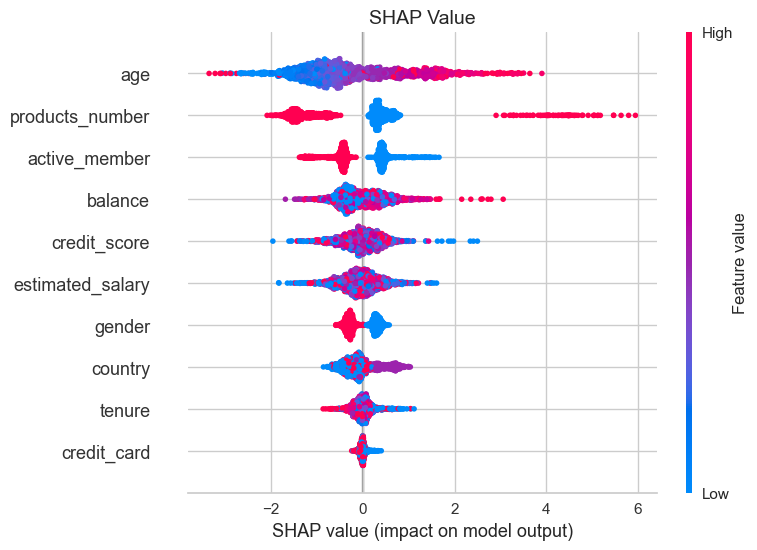

In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import pandas as pd

X_valid_df = X_valid.copy()  # 변수명 유지와 시각화를 위해 데이터프레임 형태로 맞춤
dvalid = xgb.DMatrix(X_valid_df, feature_names=X_valid_df.columns.tolist())  # XGBoost 예측용 DMatrix 생성

shap_values = best_xgb_model.get_booster().predict(dvalid, pred_contribs=True)  # 각 변수의 기여도를 SHAP 형태로 계산
shap_values = shap_values[:, :-1]  # 마지막 열은 bias 항이므로 제외

shap.summary_plot(      # shap value 시각화
    shap_values,        # plot 옵션값 설정
    X_valid_df,
    feature_names=X_valid_df.columns,
    plot_type='dot',
    show=False
)  

plt.title('SHAP Value', fontsize=14) #shap value 제목설정
plt.show() 

### SHAP Value 결과 해석

- age와 products_number가 churn 예측에 가장 큰 영향을 주는 변수로 나타났습니다.
- age는 값이 높을수록 SHAP value가 양수 방향으로 커지는 경향이 보여, 연령이 높은 고객일수록 이탈 방향으로 예측이 이동하는 경향이 있다고 볼 수 있습니다.
- products_number도 중요한 변수로 확인되었으며, 특정 상품 수 구간에서 SHAP value가 크게 양수로 나타나 이탈 예측에 강하게 반영된 것으로 해석할 수 있습니다.
- active_member는 활동 여부에 따라 SHAP 값이 뚜렷하게 나뉘어, 고객 활동성이 이탈 예측에 유의미한 영향을 주는 변수로 볼 수 있습니다.
- balance 역시 일정 수준 이상의 영향력을 보였으며, 일부 구간에서는 이탈 방향으로 예측을 높이는 역할을 한 것으로 보입니다.
- credit_score, estimated_salary, gender, country는 보조적인 설명 변수로 해석할 수 있습니다.
- tenure와 credit_card는 상대적으로 영향력이 작은 변수로 나타났습니다.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report

estimators = [
    ('catboost', best_cat_model),   # 튜닝된 CatBoost 사용
    ('lightgbm', best_lgbm_model),  # 튜닝된 LightGBM 사용
    ('gbc', best_gbc_model),        # 튜닝된 GBC 사용
    ('xgboost', best_xgb_model)     # 튜닝된 XGBoost 사용
]  # 상위 4개 모델을 전방모델로 구성

stack_model = StackingClassifier( # 최종모델 최종 학습 후 성능 극대화
    estimators=estimators,        # 옵션값 설정
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)  

stack_model.fit(X_train, y_train)  # 학습 데이터로 스태킹 모델 학습

stack_pred = stack_model.predict(X_valid)  # 검증 데이터 예측
stack_f1 = f1_score(y_valid, stack_pred)  # 검증 데이터 기준 F1 score 계산
stack_acc = accuracy_score(y_valid, stack_pred)  # 검증 데이터 기준 Accuracy 계산

print("Stacking F1 Score :", stack_f1)  # F1 score 출력
print("Stacking Accuracy :", stack_acc)  # Accuracy 출력
print(classification_report(y_valid, stack_pred))  # 클래스별 precision, recall, f1-score 출력

Stacking F1 Score : 0.6048632218844985
Stacking Accuracy : 0.87
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.75      0.51      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



### Stacking 결과 해석

- Optuna로 튜닝한 상위 4개 모델을 결합하여 스태킹 모델을 구성하였습니다.
- 스태킹 모델의 F1 score는 0.6049, Accuracy는 0.8700으로 나타났습니다.
- 이는 튜닝 후 단일 모델 중 가장 높았던 XGBoost의 F1 score 0.6102보다는 살짝 낮은 결과입니다.
- 따라서 이번 데이터에서는 여러 모델을 결합한 스태킹이 단일 최고 성능 모델을 넘어서지는 못한 것으로 해석할 수 있습니다.
- classification report를 보면 churn=1 클래스의 정밀도는 0.75, 재현율은 0.51, f1-score는 0.60으로 나타났습니다.
- 즉, 이탈이라고 예측한 고객의 정확도는 비교적 양호하지만 실제 이탈 고객을 절반 정도만 찾아낸 한계가 있었습니다.
- churn=0 클래스는 정밀도가 0.89, 재현율은 0.96, f1-score 0.92로 비교적 안정적으로 분류되었습니다.
- 본 데이터는 클래스 불균형이 존재하므로 accuracy보다 F1 score를 우선 기준으로 해석하였으며, 최종적으로는 XGBoost 단일 모델이 가장 적절한 모델이라고 판단하였습니다.

## 인사이트 및 제언

- 분석 결과, age와 products_number가 고객 이탈 예측에 가장 큰 영향을 주는 변수로 나타났습니다.
- 먼저 age의 경우, 연령이 높을수록 이탈 방향으로 예측이 이동하는 경향이 확인되었습니다. 이를 통해 고연령 고객은 현재 서비스 이용 과정에서 불편을 느끼거나, 다른 금융사의 유사 서비스로 이동할 가능성이 상대적으로 높다고 볼 수 있습니다.
- 따라서 고연령 고객을 대상으로는 더 직관적인 화면 구성, 쉬운 뱅킹 서비스, 전담 상담 채널과 같은 맞춤형 지원이 필요합니다.
- 또한 products_number 역시 중요한 변수로 나타났습니다. 특히 상품 수가 적은 고객은 은행과의 거래 관계가 상대적으로 약해, 다른 은행으로 이동할 가능성이 더 높다고 해석할 수 있습니다.
- 따라서 상품 수가 적은 고객에게는 예금, 카드, 대출, 보험 등을 연계한 추가 상품 제안이나 묶음형 혜택을 제공하여 거래 범위를 넓히는 전략이 필요합니다.
- 추가로 active_member도 중요한 변수로 확인되었으므로, 비활동 고객을 우선 관리 대상으로 설정하고 재이용을 유도하는 방안도 함께 고려할 필요가 있습니다.
- 종합하면, 고연령 고객, 상품 수가 적은 고객, 비활동 고객을 중심으로 맞춤형 유지 전략을 운영하는 것이 이탈 방지에 효과적일 것으로 판단됩니다.